In [1]:
import pandas as pd
import numpy as np

In [2]:
# 미세먼지 데이터
pm10_data = [500, 29, 29, 155, 29, 29, 29, 42, 201, 42, 42, 22, 42, 29, 29, 99, 29, 29, 
29, 150, 165, 268, 263, 258, 254, 254, 191, 121, 45, 89, 76, 32, 78, 98, 11, 24, 53,78, 
94]

# 초미세먼지 데이터
pm25_data = [295, 115, 111, 108, 168, 155, 147, 140, 130, 125, 160, 111, 99, 105, 88, 
65, 145, 156, 152, 104, 104, 104, 59, 103, 103, 33,  165, 268, 263, 258, 254, 254, 191, 
221, 178]

In [3]:
pm10 = pd.Series(pm10_data)
pm10

0     500
1      29
2      29
3     155
4      29
5      29
6      29
7      42
8     201
9      42
10     42
11     22
12     42
13     29
14     29
15     99
16     29
17     29
18     29
19    150
20    165
21    268
22    263
23    258
24    254
25    254
26    191
27    121
28     45
29     89
30     76
31     32
32     78
33     98
34     11
35     24
36     53
37     78
38     94
dtype: int64

In [4]:
pm25 = pd.Series(pm25_data)
pm25

0     295
1     115
2     111
3     108
4     168
5     155
6     147
7     140
8     130
9     125
10    160
11    111
12     99
13    105
14     88
15     65
16    145
17    156
18    152
19    104
20    104
21    104
22     59
23    103
24    103
25     33
26    165
27    268
28    263
29    258
30    254
31    254
32    191
33    221
34    178
dtype: int64

In [5]:
df = pd.DataFrame({
    '미세먼지pm10':pm10,
    '미세먼지pm25':pm25
})
df.head()

,미세먼지pm10,미세먼지pm25
0,500,295.0
1,29,115.0
2,29,111.0
3,155,108.0
4,29,168.0


In [6]:
df.shape

(39, 2)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   미세먼지pm10  39 non-null     int64  
 1   미세먼지pm25  35 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 756.0 bytes


In [8]:
df.describe()

,미세먼지pm10,미세먼지pm25
count,39.000000,35.000000
mean,103.512821,149.628571
std,103.947323,65.270967
min,11.000000,33.000000
25%,29.000000,104.000000
50%,53.000000,140.000000
75%,152.500000,173.000000
max,500.000000,295.000000


In [9]:
df.isnull().sum()

미세먼지pm10    0
미세먼지pm25    4
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(4)

In [12]:
df.duplicated().sum()   # 중복 행 수

np.int64(0)

In [13]:
# 미세먼지 pm2.5의 평균
df['미세먼지pm25'].mean()

np.float64(149.62857142857143)

In [14]:
# 결측치 채우기 - fillna()
df['미세먼지pm25'].fillna(0)

0     295.0
1     115.0
2     111.0
3     108.0
4     168.0
5     155.0
6     147.0
7     140.0
8     130.0
9     125.0
10    160.0
11    111.0
12     99.0
13    105.0
14     88.0
15     65.0
16    145.0
17    156.0
18    152.0
19    104.0
20    104.0
21    104.0
22     59.0
23    103.0
24    103.0
25     33.0
26    165.0
27    268.0
28    263.0
29    258.0
30    254.0
31    254.0
32    191.0
33    221.0
34    178.0
35      0.0
36      0.0
37      0.0
38      0.0
Name: 미세먼지pm25, dtype: float64

In [15]:
df['미세먼지pm25'].fillna(df['미세먼지pm25'].mean())

0     295.000000
1     115.000000
2     111.000000
3     108.000000
4     168.000000
5     155.000000
6     147.000000
7     140.000000
8     130.000000
9     125.000000
10    160.000000
11    111.000000
12     99.000000
13    105.000000
14     88.000000
15     65.000000
16    145.000000
17    156.000000
18    152.000000
19    104.000000
20    104.000000
21    104.000000
22     59.000000
23    103.000000
24    103.000000
25     33.000000
26    165.000000
27    268.000000
28    263.000000
29    258.000000
30    254.000000
31    254.000000
32    191.000000
33    221.000000
34    178.000000
35    149.628571
36    149.628571
37    149.628571
38    149.628571
Name: 미세먼지pm25, dtype: float64

In [16]:
df['미세먼지pm25'] = df['미세먼지pm25'].fillna(df['미세먼지pm25'].mean())
df

,미세먼지pm10,미세먼지pm25
0,500,295.000000
1,29,115.000000
2,29,111.000000
3,155,108.000000
4,29,168.000000
5,29,155.000000
6,29,147.000000
7,42,140.000000
8,201,130.000000
9,42,125.000000


In [17]:
# 미세먼지 10 1사분위수 (Q1)
q1 = df['미세먼지pm10'].quantile(.25)

# 미세먼지 10 3사분위수 (Q3)
q3 = df['미세먼지pm10'].quantile(.75)

q1, q3

(np.float64(29.0), np.float64(152.5))

In [18]:
# IQR → Q3 - Q1
iqr = q3 - q1
iqr

np.float64(123.5)

In [19]:
# 하한(최소값)
lower = q1 - 1.5 * iqr
lower

np.float64(-156.25)

In [20]:
# 상한(최대값)
upper = q3 + 1.5 * iqr
upper

np.float64(337.75)

In [22]:
# 이상치
outliers = df[(df['미세먼지pm10'] < lower) | (df['미세먼지pm10'] > upper)]
outliers

,미세먼지pm10,미세먼지pm25
0,500,295.0


In [25]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

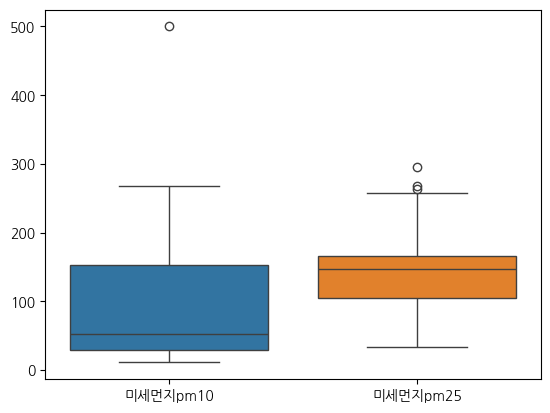

In [26]:
# 박스플롯 그래프
sns.boxplot(data=df)
plt.show()